In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [16]:
# Load the Telco Customer Churn dataset
data = pd.read_csv('Telco-Customer-Churn.csv')

# Quick look at the data
print(data.head())
print(data.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [17]:
data = data.drop('customerID', axis=1)


# Convert TotalCharges to numeric, coerce errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].median())

# Encode target variable 'Churn'
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

cat_cols = data.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

In [18]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("x_train.shape:" ,X_train.shape)
print("y_train.shape:" ,y_train.shape)
print("x_test.shape:" ,X_test.shape)
print("y_test.shape:" ,y_test.shape)

x_train.shape: (5634, 19)
y_train.shape: (5634,)
x_test.shape: (1409, 19)
y_test.shape: (1409,)


In [19]:
def build_and_train_model(neurons=32,neurons2=16, dropout=0.2, learning_rate=0.001, batch_size=32, epochs=20):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(neurons, activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(neurons2, activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc, model, history


In [20]:
neuron_options = [8, 16, 32, 64]
results = {}

for n in neuron_options:
    for i in neuron_options:
        acc, _, _ = build_and_train_model(neurons2=i,neurons=n)
        results[f"neurons={n},{i}"] = acc

results

{'neurons=8,8': 0.7948899865150452,
 'neurons=8,16': 0.7920510768890381,
 'neurons=8,32': 0.7941802740097046,
 'neurons=8,64': 0.7948899865150452,
 'neurons=16,8': 0.7970191836357117,
 'neurons=16,16': 0.7941802740097046,
 'neurons=16,32': 0.7906316518783569,
 'neurons=16,64': 0.7913413643836975,
 'neurons=32,8': 0.7892122268676758,
 'neurons=32,16': 0.7885024547576904,
 'neurons=32,32': 0.7863733172416687,
 'neurons=32,64': 0.7892122268676758,
 'neurons=64,8': 0.7963094115257263,
 'neurons=64,16': 0.7913413643836975,
 'neurons=64,32': 0.7970191836357117,
 'neurons=64,64': 0.7899219393730164}

In [21]:
lr_options = [0.1, 0.01, 0.001, 0.005]
results_lr = {}

for lr in lr_options:
    acc, _, _ = build_and_train_model(learning_rate=lr)
    results_lr[f"LR={lr}"] = acc

results_lr


{'LR=0.1': 0.7345635294914246,
 'LR=0.01': 0.7870830297470093,
 'LR=0.001': 0.7941802740097046,
 'LR=0.005': 0.7821149826049805}

In [22]:
dropout_options = [0.1, 0.2, 0.3, 0.4]
results_dropout = {}

for d in dropout_options:
    acc, _, _ = build_and_train_model(dropout=d)
    results_dropout[f"dropout={d}"] = acc

results_dropout


{'dropout=0.1': 0.7920510768890381,
 'dropout=0.2': 0.7955996990203857,
 'dropout=0.3': 0.7885024547576904,
 'dropout=0.4': 0.7913413643836975}

In [23]:
batch_options = [16, 32, 64, 128]
results_batch = {}

for b in batch_options:
    acc, _, _ = build_and_train_model(batch_size=b)
    results_batch[f"batch={b}"] = acc

results_batch


{'batch=16': 0.7984386086463928,
 'batch=32': 0.7941802740097046,
 'batch=64': 0.7948899865150452,
 'batch=128': 0.7856636047363281}

In [24]:
model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(19,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation='sigmoid')
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
X_train, y_train,
validation_split=0.2,
epochs=30,
batch_size=16,
verbose=0
)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
acc

y_pred_proba = model.predict(X_test).ravel()

auccuracy = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", auccuracy)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ROC-AUC Score: 0.8396031930558785


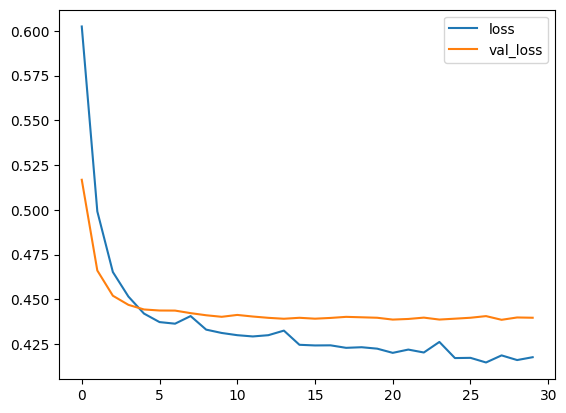

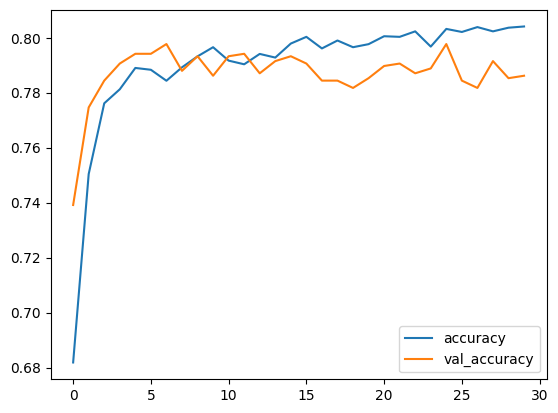

In [25]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [26]:
print(model.evaluate(X_test, y_test))


y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

y_pred_proba = model.predict(X_test).ravel()

auccuracy = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", auccuracy)


print(classification_report(y_test, y_pred_nn))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7942 - loss: 0.4221
[0.42213958501815796, 0.7941802740097046]
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step
Neural Network Accuracy: 0.794180269694819
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
ROC-AUC Score: 0.8396031930558785
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



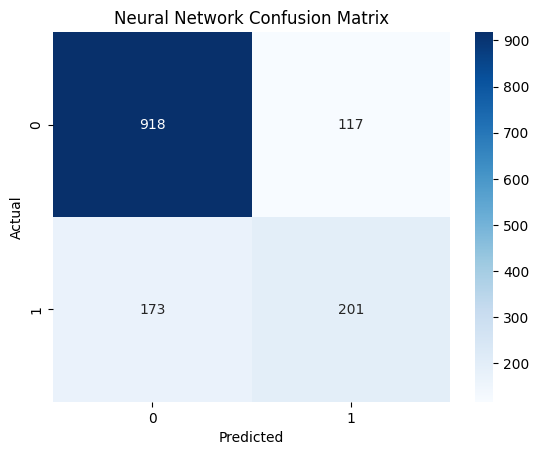

In [27]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_nn, "Neural Network Confusion Matrix")